# Gradient Descent

## Gradient Descent for Intercept
15 min

As we try to minimize loss, we take each parameter we are changing, and move it as long as we are decreasing loss. It’s like we are moving down a hill, and stop once we reach the bottom:

![](./loss_curve.svg)

The process by which we do this is called gradient descent. We move in the direction that decreases our loss the most. Gradient refers to the slope of the curve at any point.

For example, let’s say we are trying to find the intercept for a line. We currently have a guess of 10 for the intercept. At the point of 10 on the curve, the slope is downward. Therefore, if we increase the intercept, we should be lowering the loss. So we follow the gradient downwards.

![](./Linear_regression_gif_1.gif)

We derive these gradients using calculus. It is not crucial to understand how we arrive at the gradient equation. To find the gradient of loss as intercept changes, the formula comes out to be:

$$
-\frac{2}{N} \sum_{i=1}^{N} \left( y_i - (mx_i + b) \right)
$$

- N is the number of points we have in our dataset
- m is the current gradient guess
- b is the current intercept guess

Basically:

- we find the sum of y_value - (m*x_value + b) for all the y_values and x_values we have
- and then we multiply the sum by a factor of -2/N. N is the number of points we have.

### Instructions

Exercise 1

Define a function called get_gradient_at_b() that takes in a set of x values, x, a set of y values, y, a slope m, and an intercept value b.

For now, have it return b, unchanged.

In [1]:
def get_gradient_at_b(x, y, m, b):
    return b

Exercise 2

In the get_gradient_at_b() function, we want to go through all of the x values and all of the y values and compute (y - (m*x+b)) for each of them.

Create a variable called diff that has the sum of all of these values.

Instead of returning b from the get_gradient_at_b() function, return diff.

In [2]:
def get_gradient_at_b(x, y, m, b):
    diff = sum([y[i] - (m*x[i] + b) for i in range(len(x))])
    return diff

Exercise 3

Still in the get_gradient_at_b() function, define a variable called b_gradient and set it equal to the -2/N multiplied by diff.

Note: N is the number of points, i.e. the length of the x list or the y list.

Instead of returning diff, return b_gradient.

In [3]:
def get_gradient_at_b(x, y, m, b):
  N = len(x)
  diff = [y[i] - ((m * x[i]) + b) for i in range(N)]
  b_gradient = (-2/N)*sum(diff)
  return b_gradient

## Gradient Descent for Slope

9 min

We have a function to find the gradient of b at every point. To find the m gradient, or the way the loss changes as the slope of our line changes, we can use this formula:

$$
-\frac{2}{N} \sum_{i=1}^{N} x_i \left( y_i - (mx_i + b) \right)
$$

Once more:
- N is the number of points you have in your dataset
- m is the current gradient guess
- b is the current intercept guess

To find the m gradient:

- we find the sum of x_value * (y_value - (m*x_value + b)) for all the y_values and x_values we have
- and then we multiply the sum by a factor of -2/N. N is the number of points we have.

Once we have a way to calculate both the m gradient and the b gradient, we’ll be able to follow both of those gradients downwards to the point of lowest loss for both the m value and the b value. Then, we’ll have the best m and the best b to fit our data!

Exercise 1

Define a function called get_gradient_at_m() that takes in a set of x values, x, a set of y values, y, a slope m, and an intercept value b.

For now, have it return m.


In [4]:
def get_gradient_at_m(x, y, m, b):
    return m

Exercise 2

In this function, we want to go through all of the x values and all of the y values and compute x*(y - (m*x+b)) for each of them.

Create a variable called diff that has the sum of all of these values, and return it from the function.

In [5]:
def get_gradient_at_m(x, y, m, b):
    diff = [x[i] * (y[i] - (m * x[i] + b)) for i in range(len(x))]
    return diff

Exercise 3

Define a variable called m_gradient and set it equal to the -2/N multiplied by diff.

Instead of returning diff, return m_gradient.

In [6]:
def get_gradient_at_m(x, y, m, b):
    N = len(x)
    diff = [x[i] * (y[i] - ((m * x[i]) + b)) for i in range(N)]
    m_gradient = (-2/N)*sum(diff)
    return m_gradient

## Step Size and Learning Rate

15 min

Now that we know how to calculate the gradient, we want to take a “step” in that direction. However, it’s important to think about whether that step is too big or too small. We don’t want to overshoot the minimum error!

We can scale the size of the step by multiplying the gradient by a learning rate.

To find a new b value, we would say:

new_b = current_b - (learning_rate * b_gradient)

where:
- current_b is our guess for what the b value is,
- b_gradient is the gradient of the loss curve at our current guess,
- and learning_rate is proportional to the size of the step we want to take.

In a few exercises, we’ll talk about the implications of a large or small learning rate, but for now, let’s use a fairly small value.

Exercise 1

Define a function called step_gradient() that takes in x, y, m_current, b_current and learning_rate

This function will find the gradients at  m_current and b_current, and then return new m and b values that have been moved in that direction.

For now, just return the pair (m_current, b_current).


In [7]:
def step_gradient(x, y, m_current, b_current, learning_rate):
    return m_current, b_current

Exercise 2

Inside step_gradient(), find the gradient at b_current and the gradient at m_current using the functions defined before (get_gradient_at_b and get_gradient_at_m).

Store these gradients in variables called m_gradient and b_gradient, and return these from the function instead of m_current and b_current.

Return them as a list.

In [8]:
def step_gradient(x, y, m_current, b_current, learning_rate):
    b_gradient = get_gradient_at_b(x, y, m_current, b_current)
    m_gradient = get_gradient_at_m(x, y, m_current, b_current)
    return m_gradient, b_gradient

Exercise 3

Let’s try to move the parameter values in the direction of the gradient at a rate of learning_rate = 0.01.

Create variables called b and m:
- b should be b_current - (learning_rate * b_gradient)
- m should be m_current - (learning_rate * m_gradient)

Return the pair b and m from the function.

In [9]:
def step_gradient(x, y, m_current, b_current, learning_rate):
    m_gradient = get_gradient_at_m(x, y, m_current, b_current)
    b_gradient = get_gradient_at_b(x, y, m_current, b_current)
    m = m_current - (learning_rate * m_gradient)
    b = b_current - (learning_rate * b_gradient)
    return m, b

Exercise 4

We have provided Sandra’s lemonade data once more. We have a guess for what we think the b and m might be.

Call your function to perform one step of gradient descent. Store the results in the variables b and m.

Great! We have a way to step to new b and m values! Next, we will call this function a bunch, in order to move those values towards lower and lower loss.

In [10]:
# Data
months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
revenue = [52, 74, 79, 95, 115, 110, 129, 126, 147, 146, 156, 184]

In [11]:
# Current guess
m = 0
b = 0
learning_rate = 0.01

# Compute a gradient step
m, b = step_gradient(months, revenue, m, b, learning_rate)
print(m, b)

17.78333333333333 2.355


## Convergence

4 min

How do we know when we should stop changing the parameters m and b? How will we know when our program has learned enough?

To answer this, we have to define convergence. Convergence is when the loss stops changing (or changes very slowly) when parameters are changed.

Hopefully, the algorithm will converge at the best values for the parameters m and b.

In [16]:
ms = []
bs = []
m, b = 0, 0
for i in range(1400):
    m, b = step_gradient(months, revenue, m, b, learning_rate)
    ms.append(m)
    bs.append(b)

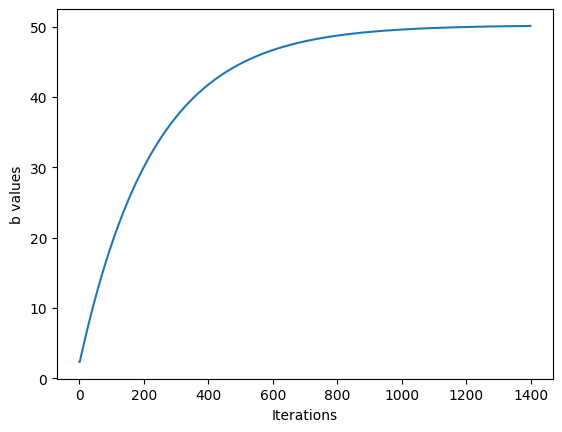

In [17]:
import matplotlib.pyplot as plt

iterations = range(len(bs))

plt.plot(iterations, bs)
plt.xlabel("Iterations")
plt.ylabel("b values")
plt.show()


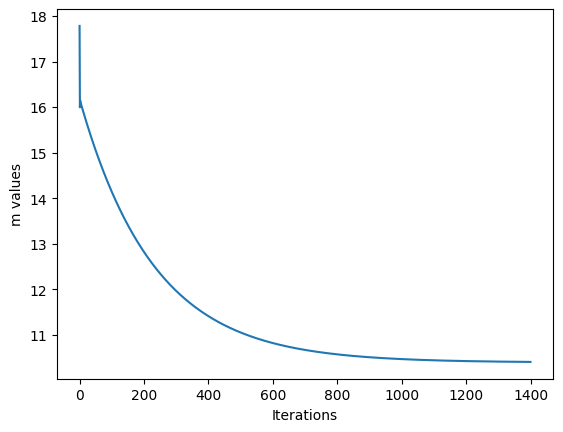

In [19]:
import matplotlib.pyplot as plt

plt.plot(range(len(ms)), ms)
plt.xlabel("Iterations")
plt.ylabel("m values")
plt.show()

In [53]:
def gradient_descent(x, y, learning_rate, num_iterations):
  m = 0
  b = 0
  for i in range(num_iterations):
    m, b = step_gradient(x, y, m, b, learning_rate)
  return m, b

In [54]:
# Compute gradient descent
m, b = gradient_descent(months, revenue, 0.01, 1000)
print(m, b)

10.463427732364998 49.60215351339813


In [55]:
# Compute y_pred
y_pred = [m*x + b for x in months]

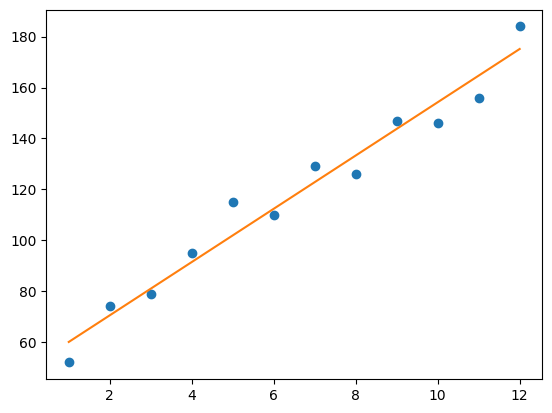

In [56]:
plt.plot(months, revenue, "o")
plt.plot(months, y_pred)
plt.show()